In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind
from config import Results_OUTPUT_AUTISM_PATH, Results_OUTPUT_PUBLIC_PATH

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)


In [19]:
df_Autism = pd.read_csv(Results_OUTPUT_AUTISM_PATH)
df_Autism.head()

,platform,hashtag,status_id,created_at,account_id,account_name,url,replies_count,reblogs_count,favourites_count,...,hf_sentiment_label,hf_sentiment_polarity,sentiment_subjectivity,toxicity_toxicity,toxicity_severe_toxicity,toxicity_obscene,toxicity_identity_attack,toxicity_insult,toxicity_threat,toxicity_sexual_explicit
0,mastodon,ActuallyAutistic,115703666321425959,2025-12-12T00:03:56+00:00,112892314651965893,SeaFury@aus.social,https://aus.social/@SeaFury/115703666236516807,8,1,10,...,neutral,-0.088926,0.393939,0.000626,0.000002,0.000046,0.000087,0.000126,0.000023,0.000021
1,mastodon,ActuallyAutistic,115703332648599760,2025-12-11T22:39:05+00:00,754391,oddtail@meow.social,https://meow.social/@oddtail/115703332550342938,4,4,1,...,negative,-0.878346,0.582267,0.378461,0.000304,0.381367,0.000756,0.030566,0.000180,0.001330
2,mastodon,ActuallyAutistic,115703300727439614,2025-12-11T22:30:56+00:00,113047730416315829,punishmenthurts@autistics.life,https://autistics.life/@punishmenthurts/115703300514759637,0,0,0,...,neutral,0.202066,0.540402,0.028665,0.000004,0.000426,0.000346,0.018935,0.000068,0.000071
3,mastodon,ActuallyAutistic,115703106698743556,2025-12-11T21:41:39.002000+00:00,111738926606148138,filmfreak75,https://mastodon.social/@filmfreak75/115703106698743556,0,2,3,...,neutral,-0.075480,0.383333,0.000509,0.000001,0.000037,0.000074,0.000122,0.000020,0.000016
4,mastodon,ActuallyAutistic,115703011287204633,2025-12-11T21:17:23.142000+00:00,111738926606148138,filmfreak75,https://mastodon.social/@filmfreak75/115703011287204633,0,1,3,...,neutral,-0.277994,0.650000,0.000533,0.000002,0.000045,0.000068,0.000127,0.000020,0.000016


In [20]:
df_Public = pd.read_csv(Results_OUTPUT_PUBLIC_PATH)
df_Public.head()

,platform,status_id,created_at,account_id,account_name,url,replies_count,reblogs_count,favourites_count,sensitive,...,hf_sentiment_label,hf_sentiment_polarity,sentiment_subjectivity,toxicity_toxicity,toxicity_severe_toxicity,toxicity_obscene,toxicity_identity_attack,toxicity_insult,toxicity_threat,toxicity_sexual_explicit
0,mastodon,115704294875349540,2025-12-12T02:43:45+00:00,109335995887504274,aatheus@batchats.net,https://batchats.net/@aatheus/115704294646761171,0,0,0,False,...,negative,-0.573710,0.463810,0.000544,0.000001,0.000034,0.000079,0.000121,0.000025,0.000018
1,mastodon,115704294862667880,2025-12-12T01:04:40+00:00,111625485253834831,fansided@flipboard.com,https://flipboard.com/@fansided/lawless-republic-ai41ub4dz/-/a-RIyZmfj3QhWdZseIWGPQNQ%3Aa%3A61877088-%2F0,0,0,0,False,...,neutral,-0.213679,0.625000,0.008250,0.000005,0.000267,0.000402,0.001497,0.000433,0.000064
2,mastodon,115704294841750011,2025-12-12T02:43:39+00:00,111533090849780269,Shoujofan@burnthis.town,https://burnthis.town/@Shoujofan/115704294258022157,0,0,0,False,...,neutral,0.066975,0.375000,0.001234,0.000004,0.000157,0.000205,0.000189,0.000027,0.000055
3,mastodon,115704294819079817,2025-12-12T02:43:48.275000+00:00,109949272782740620,SteveThompson,https://mastodon.social/@SteveThompson/115704294819079817,0,0,0,False,...,negative,-0.682325,0.433333,0.006180,0.000006,0.000076,0.001855,0.001813,0.000112,0.000159
4,mastodon,115704294671789916,2025-12-12T02:43:46.025000+00:00,115243285764892793,valhoga01,https://mastodon.social/@valhoga01/115704294671789916,0,0,0,False,...,negative,-0.511209,0.500000,0.000486,0.000001,0.000029,0.000070,0.000137,0.000016,0.000012


In [21]:
print(f"Autism Shape is {df_Autism.shape}")
print(f"Public Shape is {df_Public.shape}")

Autism Shape is (3878, 23)
Public Shape is (3870, 22)


In [22]:
print(f"Autism table columns: {df_Autism.columns.tolist()}")
print(f"Public table columns: {df_Public.columns.tolist()}")


Autism table columns: ['platform', 'hashtag', 'status_id', 'created_at', 'account_id', 'account_name', 'url', 'replies_count', 'reblogs_count', 'favourites_count', 'sensitive', 'visibility', 'content_text', 'hf_sentiment_label', 'hf_sentiment_polarity', 'sentiment_subjectivity', 'toxicity_toxicity', 'toxicity_severe_toxicity', 'toxicity_obscene', 'toxicity_identity_attack', 'toxicity_insult', 'toxicity_threat', 'toxicity_sexual_explicit']
Public table columns: ['platform', 'status_id', 'created_at', 'account_id', 'account_name', 'url', 'replies_count', 'reblogs_count', 'favourites_count', 'sensitive', 'visibility', 'content_text', 'hf_sentiment_label', 'hf_sentiment_polarity', 'sentiment_subjectivity', 'toxicity_toxicity', 'toxicity_severe_toxicity', 'toxicity_obscene', 'toxicity_identity_attack', 'toxicity_insult', 'toxicity_threat', 'toxicity_sexual_explicit']


In [23]:
df_Autism = df_Autism.dropna(subset=["content_text"])
df_Public = df_Public.dropna(subset=["content_text"])
df_Autism = df_Autism[df_Autism["content_text"].str.strip().str.len() > 0]
df_Public = df_Public[df_Public["content_text"].str.strip().str.len() > 0]
df_Autism.shape, df_Public.shape

((3878, 23), (3870, 22))

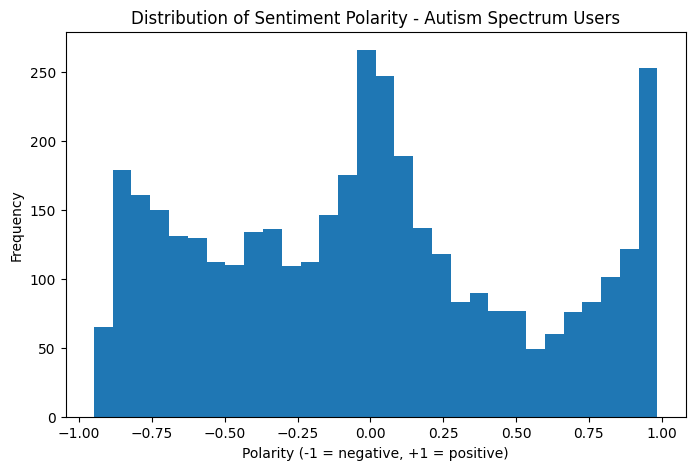

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df_Autism["hf_sentiment_polarity"], bins=30)
plt.title("Distribution of Sentiment Polarity - Autism Spectrum Users")
plt.xlabel("Polarity (-1 = negative, +1 = positive)")
plt.ylabel("Frequency")
plt.show()


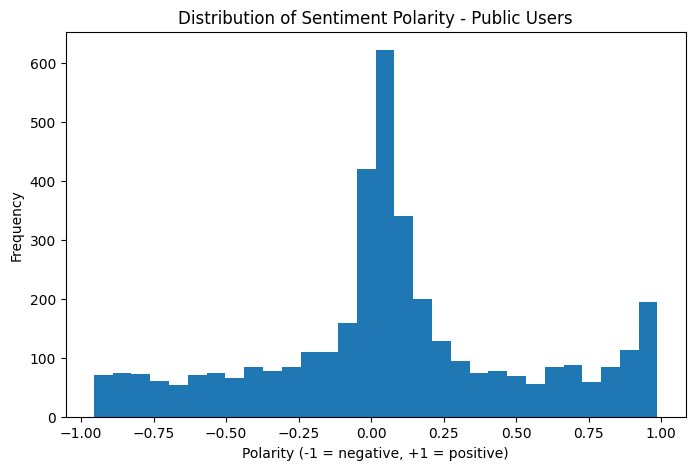

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df_Public["hf_sentiment_polarity"], bins=30)
plt.title("Distribution of Sentiment Polarity - Public Users")
plt.xlabel("Polarity (-1 = negative, +1 = positive)")
plt.ylabel("Frequency")
plt.show()

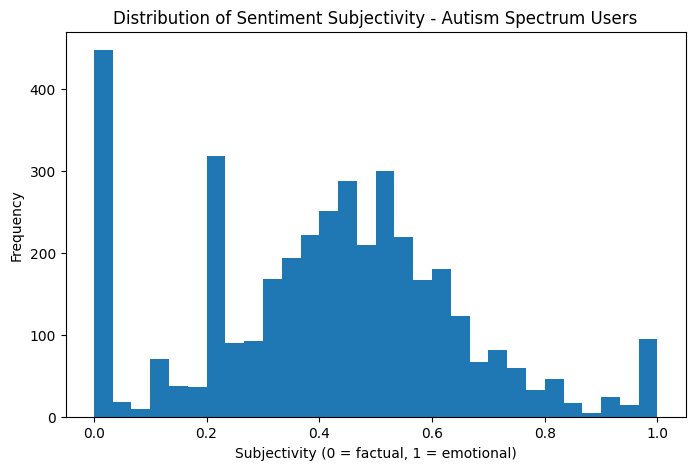

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df_Autism["sentiment_subjectivity"], bins=30)
plt.title("Distribution of Sentiment Subjectivity - Autism Spectrum Users")
plt.xlabel("Subjectivity (0 = factual, 1 = emotional)")
plt.ylabel("Frequency")
plt.show()


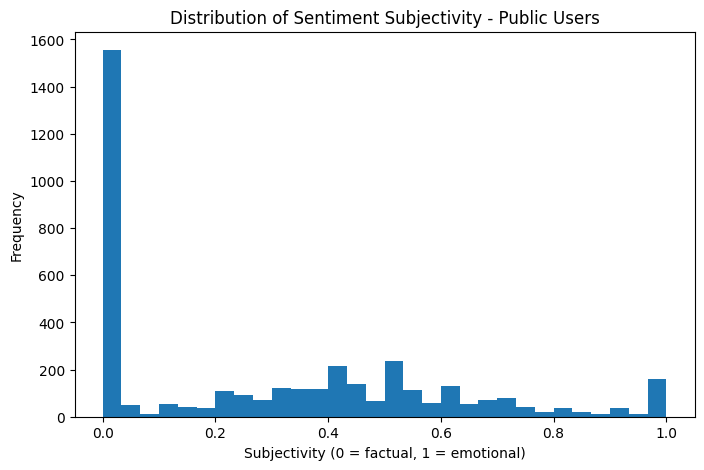

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df_Public["sentiment_subjectivity"], bins=30)
plt.title("Distribution of Sentiment Subjectivity - Public Users")
plt.xlabel("Subjectivity (0 = factual, 1 = emotional)")
plt.ylabel("Frequency")
plt.show()


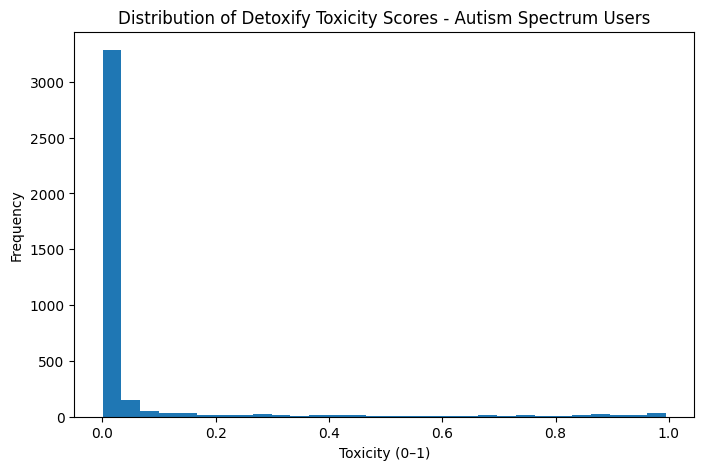

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df_Autism["toxicity_toxicity"], bins=30)
plt.title("Distribution of Detoxify Toxicity Scores - Autism Spectrum Users")
plt.xlabel("Toxicity (0–1)")
plt.ylabel("Frequency")
plt.show()


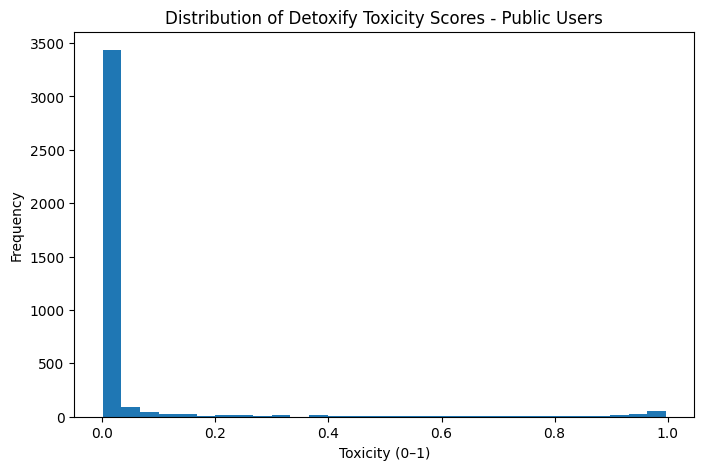

In [31]:

plt.figure(figsize=(8,5))
plt.hist(df_Public["toxicity_toxicity"], bins=30)
plt.title("Distribution of Detoxify Toxicity Scores - Public Users")
plt.xlabel("Toxicity (0–1)")
plt.ylabel("Frequency")
plt.show()


In [13]:
df_Autism.nlargest(10, "toxicity_toxicity")[["content_text", "toxicity_toxicity"]]


,content_text,toxicity_toxicity
1178,"GOD FUCKING DAMNIT I'M SO ANGRY THAT I COULD BITE MY OWN EYEBALLS hey, friendo.. you're overstimulated by being itchy and sore. go get a shower. # audhd # autism # adhd # disability",0.995423
1400,"Me: *sitting peacefully at my desk, nerding* Me: *snacks on some onion at my desk* Me: *sniff sniff* ""What the---? OH FUCK!!!! *abruptly flies out of my chair crashing through lots of stuff like some sort of fucking cartoon or some shit* I WAS PREPPING TO HOT GLUE STUFF LIKE AN HOUR AGO!!!"" # AuDHD",0.993246
2008,"To all the misunderstood, weirdos, unintentional ""assholes"", unique and mega talented autistic minds out there surfing the daily challenges of this world.... YOU fucking rock! 🤟 Know that you are loved! 🙌🤗 # autistic # autism # actuallyautistic # autisticlegion # aspergers # autismawareness # autismacceptance # asd # adhd # autismo # autismspectrum # neurodiversity # neurodivergent # autismawarenessmonth # autismworld https://www. youtube.com/watch?v=ej2c013Hcr A",0.991268
3517,"seriously, there have been people for from between one and three million years, depending on your definition. You do not get to declare these nation state asshole factories of the last few thousand years, ""normal,"" WTF is the matter with you, turn this shit around, you idiots . @autistics # ActuallyAutistic # actuallyautistic # autism # philosophy",0.991115
216,"Feeling a bit of an asshole for saying this, but meetings without arbitration/moderation are not accessible . Even less if everyone talks at the same time disregarding collisions/interrupting, and/or there's multiple conversations going on at the same time. Less of all if everyone shouts . And in low light conditions when one can't read facial expressions or sometimes even identify who's talking... well, some people I know overload and run the fuck away. Good thing I didn't go for the old meltdown, it's an ugly thing to see in a middle-aged tranny. # ActuallyAutistic",0.990401
442,"don't tell me how you're a weirdo who answers rhetorical questions, tell me about how you're a normal person and WHAT THE FUCK IS A RHETORICAL ""QUESTION??!?!?!"" . # actuallyautistic @autistics # ActualllyAutistic # autism",0.990017
1708,"""RFK Jr. is just an ignorant asshole"", says an autistic kid that became an adult who holds down a job, pays taxes, contributes 2 cute formulas and a revolution in #mathematics #education to society. \n\n #actuallyautistic #autism #autismawareness #autismacceptance #neurodivergent #polynomials #calculus RE: https://bsky.app/profile/did:plc:mlmouohgzbjofidukcp4pxf2/post/3lmxl6lrj3c2a",0.990012
156,"[P] I sometimes think about how much more fun and diverse everything would be without the narcissism of neurotypical slurry... And yeah, it'd be better. We might even get a workable utopia going that values all kinds equally. Fuck neurotypicals and fuck their collective narcissism. It's just so damn depressing. # psychology # actuallyautistic # neurotypicals # depression -8",0.989460
1057,"Looking for a nice friendly online # AuDHD community and all I can find is fucking discord, facebook, substack and more of that techno-fascist crap.",0.989343
1863,"This pastor is a theofascist and a moron ""Lake Worth-area private school cancels # AutismAwarenessWeek after pastor calls it 'demonic'"" # Autism # AutismAwareness https://www. wptv.com/news/palm-beach-count y/region-c-palm-beach-county/lake-worth-area-private-school-cancels-autism-awareness-week-after-pastor-calls-it-demonic",0.988319


In [14]:
df_Public.nlargest(10, "toxicity_toxicity")[["content_text", "toxicity_toxicity"]]

,content_text,toxicity_toxicity
480,I WISH I CAN PUNCH THESE PENNYRILE ELECTRIC FUCKERS IN THE THR**TS!!! I WISH I CAN SEND D**TH THR**TS TO PENNYRILE ELECTRIC WITHOUT DEALING WITH AI-GENERATED CENSORSHIP VIOLATING MY 1ST AMENDMENT RIGHTS!!! DEATH TO PENNYRILE ELECTRIC & DEATH TO HOPKINSVILLE!!!,0.997536
1623,YEAH FROZEN IN TIME BECAUSE YOU FUCKS CANT COME UP WITH NEW STUFF ANYMORE,0.997101
2006,TELL ME YOU'RE NOT A DICKTATOR WITHOUT TELLING ME \n\nHOLY SHIT\n\nHE SAYS THE QUIET PART OUT LOUD\n\nHEY DICKTATOR DONNY? YOU WANNA BE LIKE THOSE FASCIST THUGS? THOSE WHO HAVE NO CONCERN FOR CITIZEN RIGHTS? \n\nHEY DOUCHEBAG...FUCK YOU. !! RE: https://bsky.app/profile/did:plc:t6ubj2wlhc34awzcymh3qpur/post/3m7qwap6m722u,0.996698
2180,god i'm so gay..... HOSPITAL????????? WTF I FUCKING HATE THIS GAME IT'S SPARKLECARE SLOP FUUUUUUUUUUCK,0.996597
2054,Fuck you and the horseradish cheddar you rode in on # CheesyOneLiners # HashTagGames,0.995887
3132,"IF THERE WERE MEANINGFUL OVERSIGHT OVER THE SITUATION THIS SITUATION WOULD NOT EXIST Any argument revolving around ""but judges"" or ""but republican oligarchs"" and a leash on Trump is STUPID FUCKING SHIT. meaningful oversight HAS NOT BEEN EXECUTED so YOU CANNOT ASK PEOPLE TO TRUST THAT IT WILL. given that ICE IS THE GESTAPO",0.995423
2669,FUCK GRAND THEFT AUTO VI. FUCK ROCKSTAR. GLORY TO THE UNIONS.,0.995342
2937,"WE SAW HIM DEPLOY NATIONAL GUARD TO CALIFORNIA ILLEGALLY. WHAT DEBATE IS THERE TO BE HAD. there's a stupid idiot vortex where some people say ""even if he is a fascist autocratic tyrant, the system will restrain him"" and then he does fascist things and the system sorta stops him they go ""See? He's not a fascist."" Pure idiot drivel.",0.995208
3675,"deferring to the ""wisdom"" of elders is pretty precisely how we got here. they do not have wisdom: they are the problem. people will bloviate all the excuses not to fix the problem, 'if trump were gone the systemic forces which created him would still be there' STUPID FUCKING SHIT. yes there would still be racist sexist slavers but THEY WOULD HAVE BEEN MEANINGFULLY OPPOSED instead of people shrugging and trusting old people to set aside their comfort and DO THEIR FUCKING JOB.",0.995191
3275,"the point is that moral reasoning won't work on deep rationalizations that affect old people and their sense of contributing, their ugly selfishness, continuing to center their BAD STUPID BOOMER SHIT in a MASSIVE FUCKING CRISIS. moral reasoning won't work. they need to be afraid. they need to be as afraid of their constituents as their constituents are afraid of BEING ROUNDED UP AND SENT TO THE CAMPS. WHAT DO YOU MEAN ""THAT ISN'T GOING TO HAPPEN""?",0.995093


In [15]:
false_positives = df[
    (df["sentiment_polarity"] > -0.1) &
    (df["toxicity_toxicity"] > 0.4)
]

false_positives[["content_text", "sentiment_polarity", "toxicity_toxicity"]].head(20)


NameError: name 'df' is not defined

In [ ]:
len(false_positives), len(df)


(56, 2098)

In [ ]:
100 * len(false_positives) / len(df)


2.669208770257388

In [ ]:
df[["sentiment_polarity", "toxicity_toxicity"]].corr()


,sentiment_polarity,toxicity_toxicity
sentiment_polarity,1.000000,-0.125648
toxicity_toxicity,-0.125648,1.000000


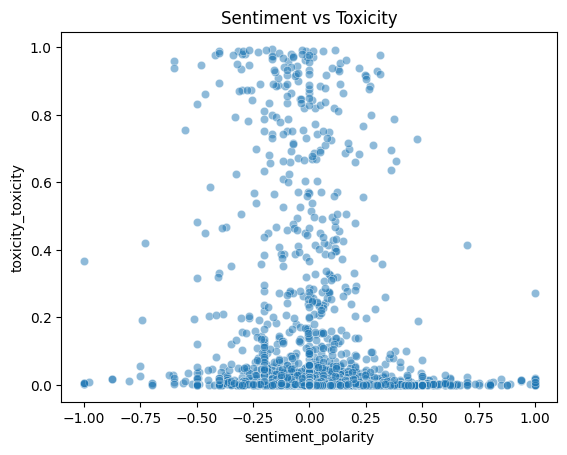

In [16]:
sns.scatterplot(x="sentiment_polarity", y="toxicity_toxicity", data=df_Autism, alpha=0.5)
plt.title("Sentiment vs Toxicity")
plt.show()


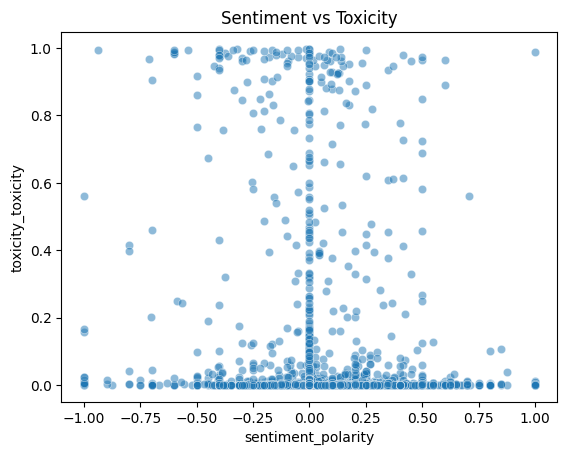

In [17]:
sns.scatterplot(x="sentiment_polarity", y="toxicity_toxicity", data=df_Public, alpha=0.5)
plt.title("Sentiment vs Toxicity")
plt.show()


In [ ]:
df.groupby("hashtag")["toxicity_toxicity"].mean().sort_values(ascending=False)


hashtag
autismadvocate            0.113796
autism                    0.084454
aspergers                 0.079029
ActuallyAutistic          0.074460
Autistic                  0.061101
AuDHD                     0.057847
autismacceptance          0.056681
AutisticPride             0.052713
autismawarenessmonth      0.050810
autismawareness           0.035210
autismspectrum            0.031303
autismspectrumdisorder    0.030275
asd                       0.020125
asc                       0.017276
autismlife                0.015497
autismjourney             0.007267
autismrocks               0.002454
Name: toxicity_toxicity, dtype: float64

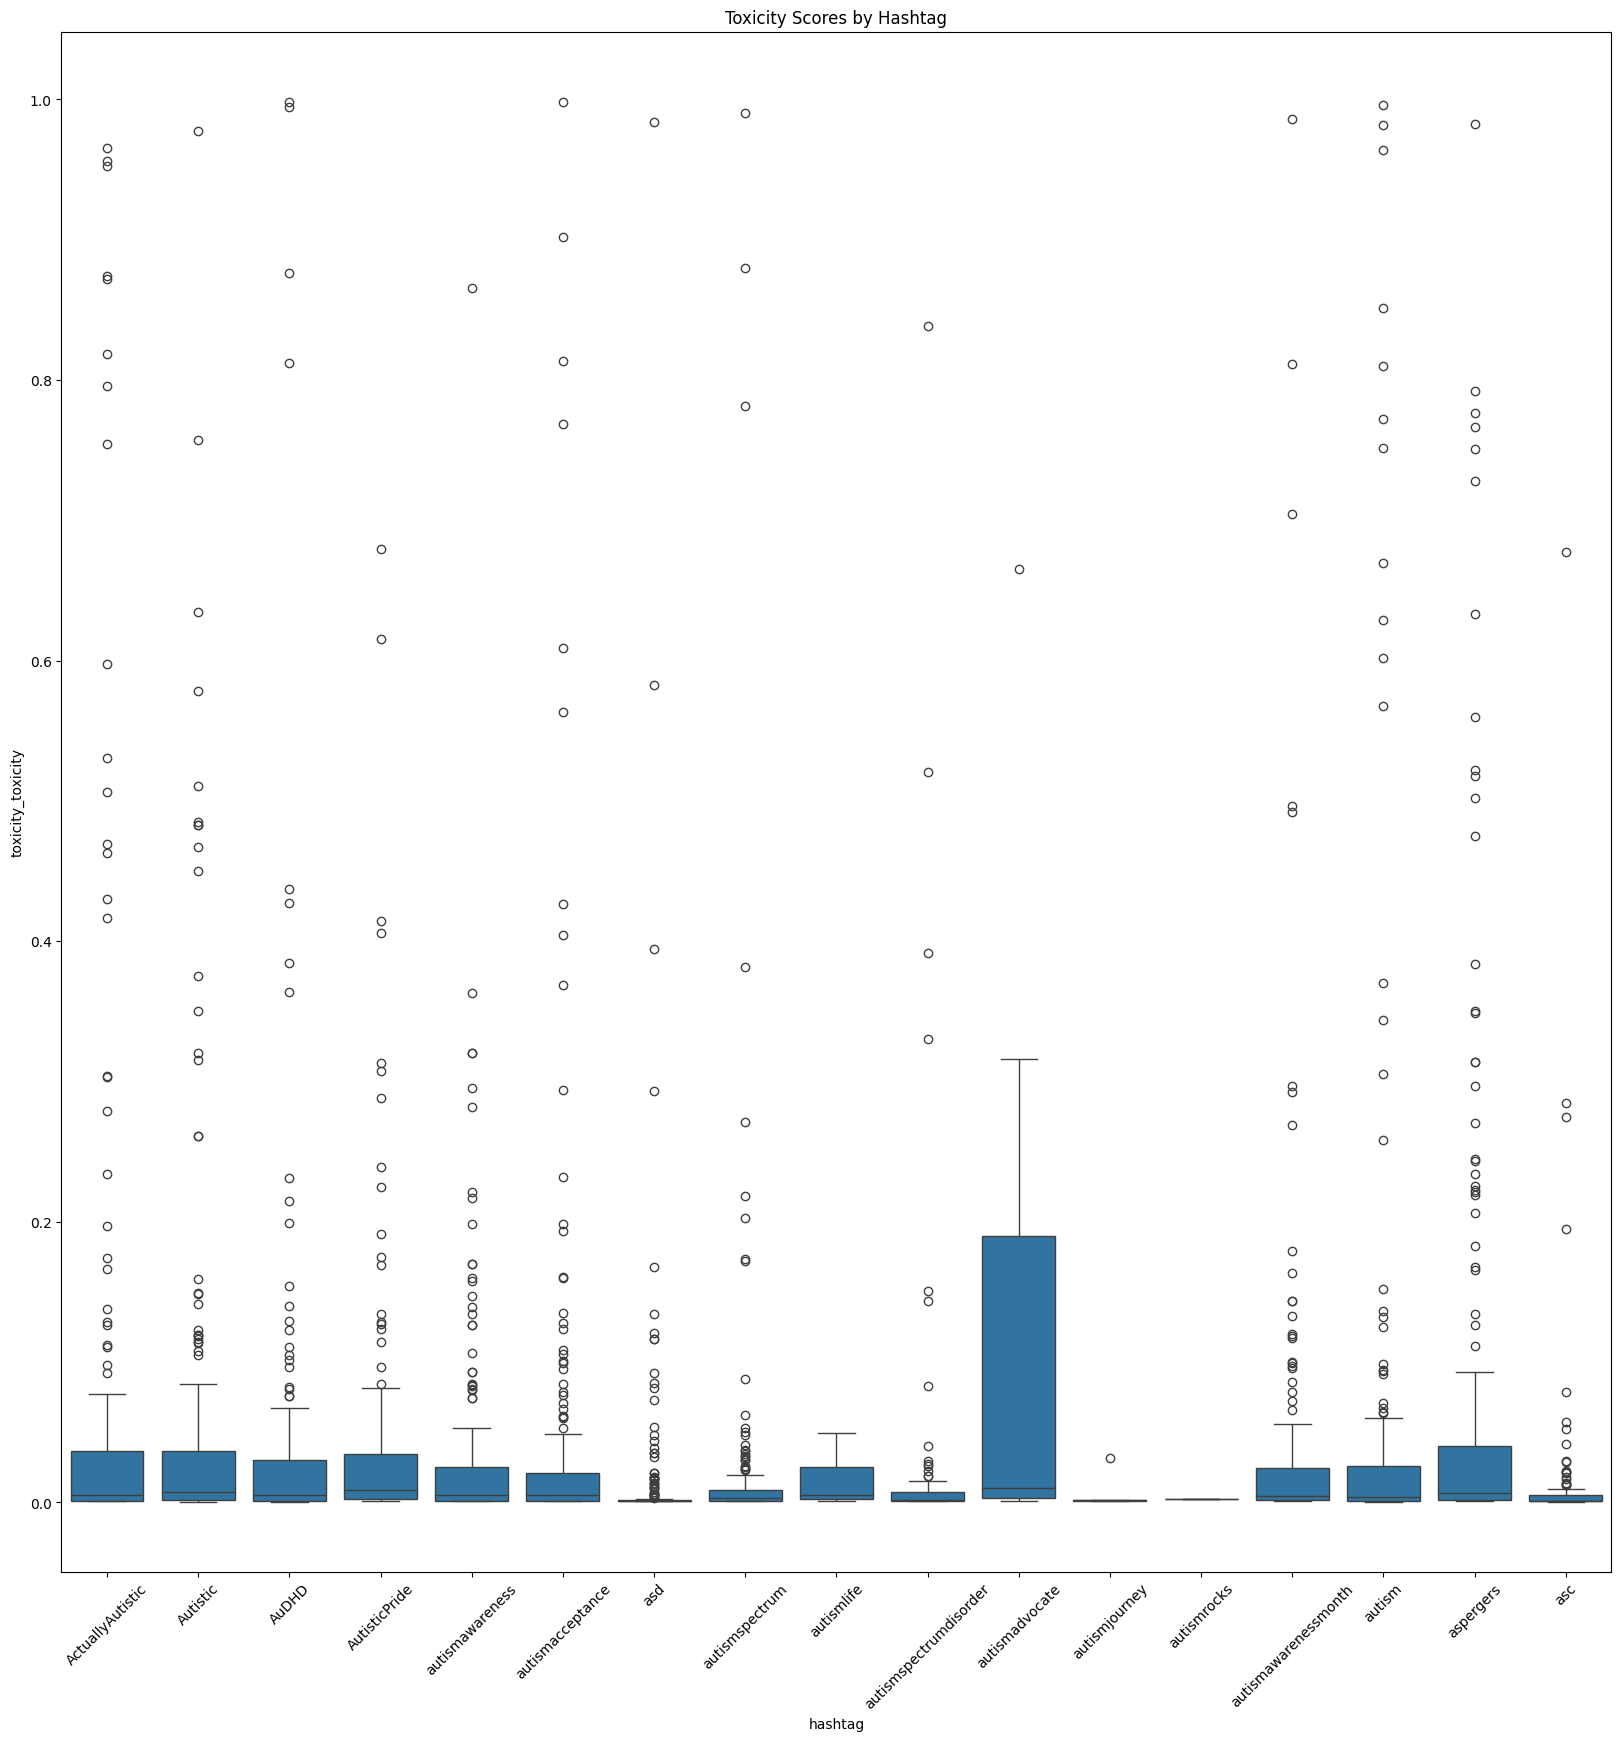

In [ ]:
plt.figure(figsize=(20,20))
sns.boxplot(x="hashtag", y="toxicity_toxicity", data=df)
plt.xticks(rotation=45)
plt.title("Toxicity Scores by Hashtag")
plt.show()


In [ ]:
aa = df[df["hashtag"]=="ActuallyAutistic"]["toxicity_toxicity"]
other = df[df["hashtag"]!="ActuallyAutistic"]["toxicity_toxicity"]

ttest_ind(aa, other, equal_var=False)


TtestResult(statistic=np.float64(1.8371824371596905), pvalue=np.float64(0.06751939066516129), df=np.float64(222.04997583399276))

In [ ]:
cohen_d = (aa.mean() - other.mean()) / np.sqrt((aa.std()**2 + other.std()**2) / 2)
cohen_d


np.float64(0.15235602362683948)